In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder

In [2]:

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/blastchar/telco-customer-churn


In [3]:
churn_data=pd.read_csv(f'{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv')
churn_data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
churn_data.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
churn_data.dtypes.value_counts()

object     18
int64       2
float64     1
Name: count, dtype: int64

In [6]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Numerical= make_column_selector(dtype_include=np.number)
# Categorical= make_column_selector(dtype_exclude=np.number)

# preprocessor= make_column_transformer((StandardScaler(),Numerical),(OrdinalEncoder(),Categorical))

# data_preprocess= preprocessor.fit_transform(churn_data)

# statistique des churns

In [8]:
churn_data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

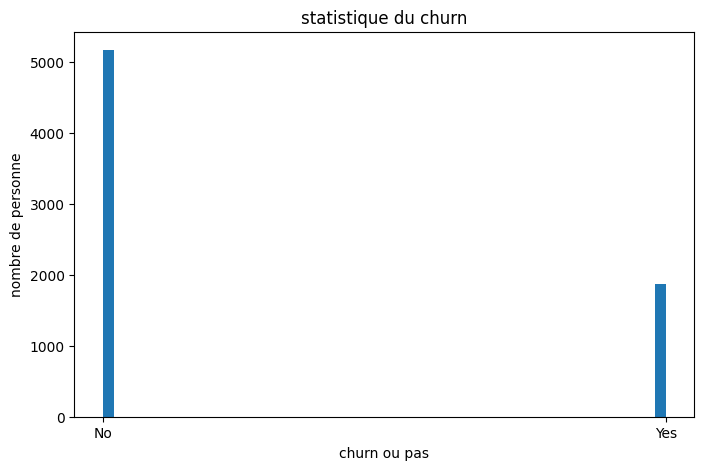

In [9]:
plt.figure(figsize=(8,5))
plt.hist(churn_data['Churn'],bins=50)
plt.xlabel('churn ou pas')
plt.ylabel('nombre de personne')
plt.title('statistique du churn')
plt.show()

# Profil des clients

<Axes: xlabel='gender', ylabel='count'>

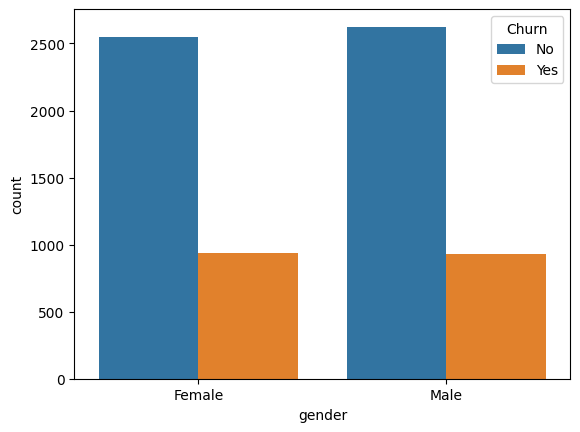

In [10]:
sns.countplot(x="gender", hue="Churn", data=churn_data)

<Axes: xlabel='SeniorCitizen', ylabel='count'>

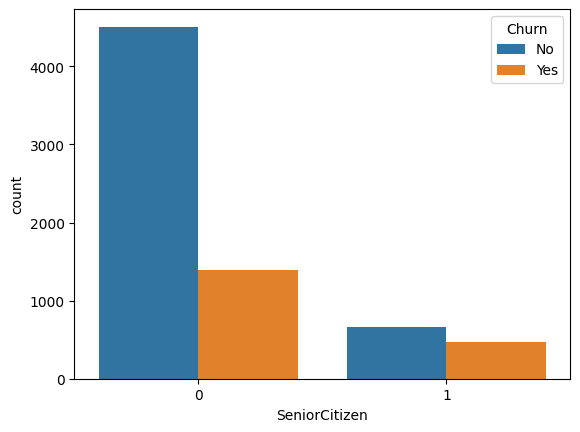

In [11]:
sns.countplot(x="SeniorCitizen", hue="Churn", data=churn_data)

<Axes: xlabel='Dependents', ylabel='count'>

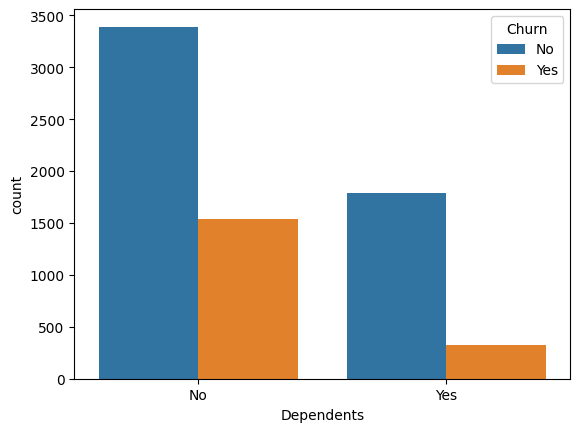

In [12]:
sns.countplot(x="Dependents", hue="Churn", data=churn_data)

<Axes: xlabel='Partner', ylabel='count'>

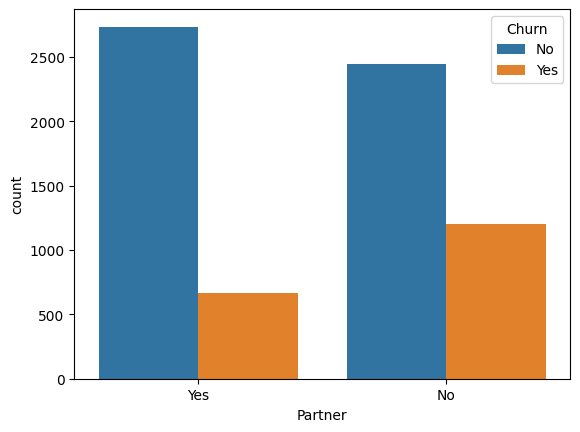

In [13]:
sns.countplot(x="Partner", hue="Churn", data=churn_data)

# Variable contractuelle

<Axes: xlabel='Contract', ylabel='count'>

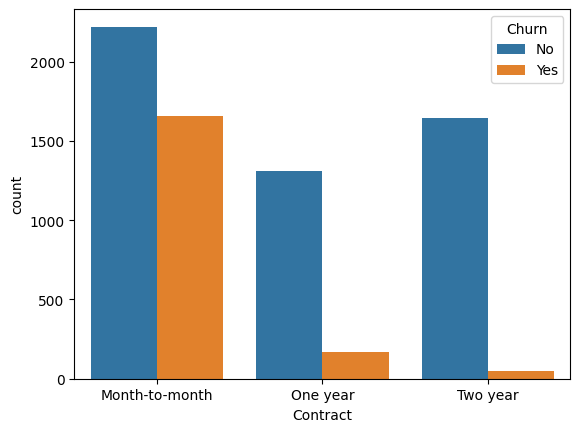

In [14]:
sns.countplot(x="Contract", hue="Churn", data=churn_data)

<Axes: xlabel='Churn', ylabel='tenure'>

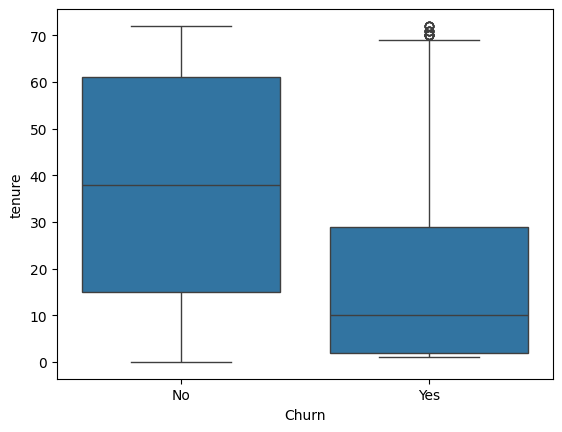

In [15]:
sns.boxplot(x="Churn", y="tenure", data=churn_data)

# Variables financières

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

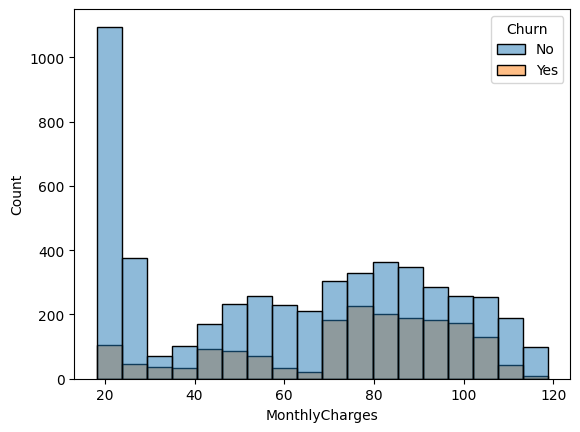

In [16]:
sns.histplot(data=churn_data, x="MonthlyCharges", hue="Churn")

# Services utilisés

<Axes: xlabel='TechSupport', ylabel='count'>

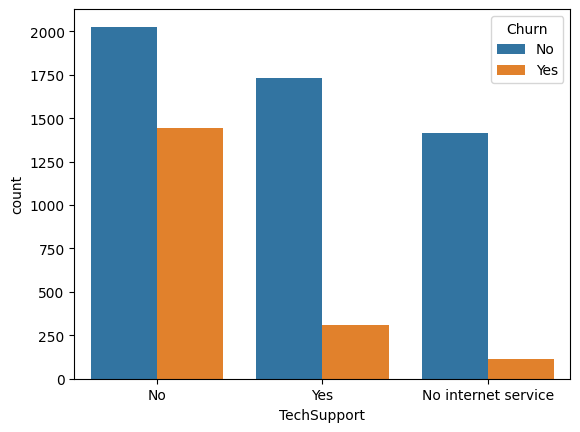

In [17]:
sns.countplot(x="TechSupport", hue="Churn", data=churn_data)

# Corrélations (variables numériques)

<Axes: >

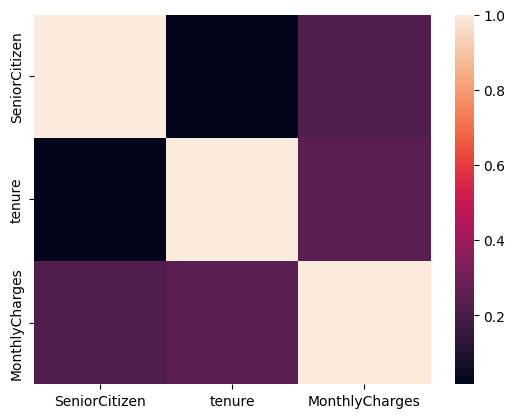

In [18]:
sns.heatmap(churn_data.corr(numeric_only=True), annot=False)